# ***Evaluation and Visualization***

In [ ]:
# Class names in order
classes_list = classes

test_generator.reset() # Reset test generator before evaluation

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss    : {test_loss:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.9369 - loss: 0.2076

Test Accuracy: 93.69%
Test Loss    : 0.2076


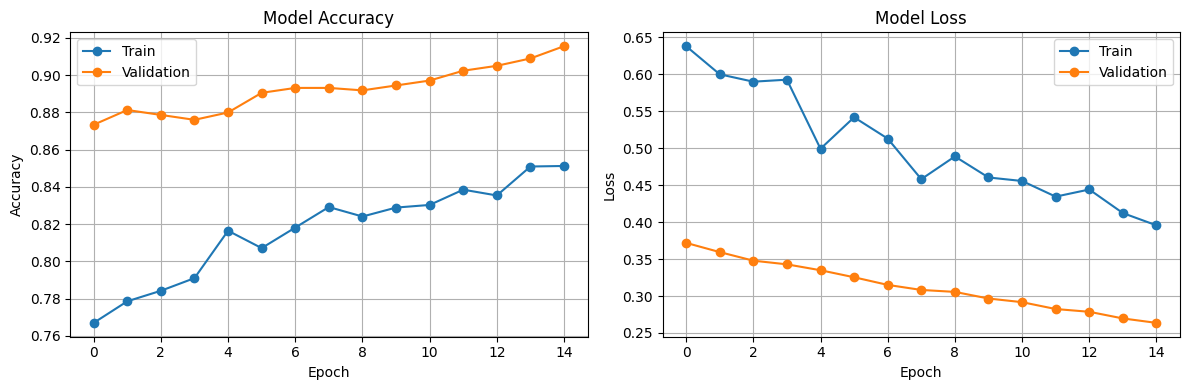

24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 258ms/step


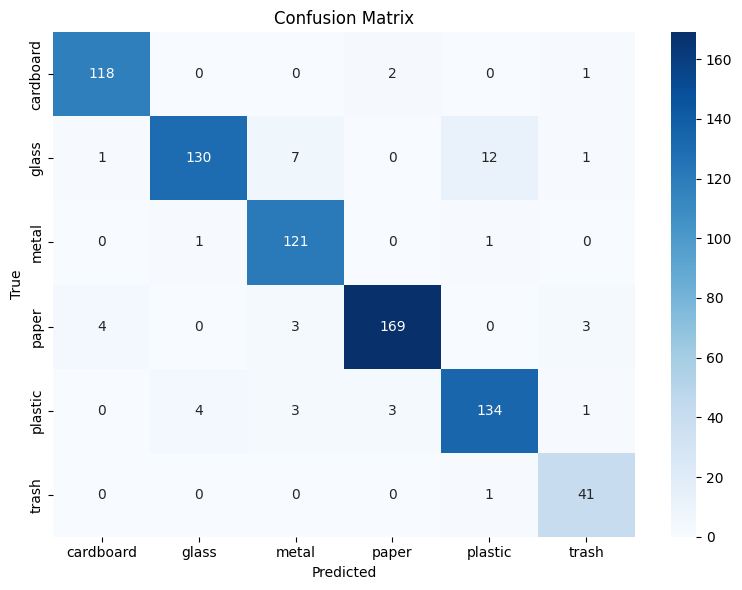


Classification Report:
              precision    recall  f1-score   support

   cardboard       0.96      0.98      0.97       121
       glass       0.96      0.86      0.91       151
       metal       0.90      0.98      0.94       123
       paper       0.97      0.94      0.96       179
     plastic       0.91      0.92      0.91       145
       trash       0.87      0.98      0.92        42

    accuracy                           0.94       761
   macro avg       0.93      0.94      0.94       761
weighted avg       0.94      0.94      0.94       761



In [ ]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train',      marker='o')
plt.plot(history.history['val_accuracy'], label='Validation', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train',      marker='o')
plt.plot(history.history['val_loss'], label='Validation', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Predict on test set
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = test_generator.classes  # Already integer labels

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_true_classes, y_pred_classes),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=classes_list, yticklabels=classes_list
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Print precision, recall, and F1-score for each class
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes,
                             target_names=classes_list, zero_division=0))